Forme de la base de données : (32735, 16)
Nombre de vols en retard au départ : 12799

--- ANALYSE DES VOLS EN RETARD AU DÉPART ---
Vols ayant TOTALEMENT rattrapé (arrivée en avance) : 3317 (25.9%)
Vols avec retard maintenu (±5 min) : 2905 (22.7%)
Vols avec retard aggravé : 3015 (23.6%)

--- Retards à l'arrivée selon le retard au départ ---
                          mean  median        std  count
dep_delay_category                                      
0-10 min             -1.215106    -3.0  18.706235   4528
10-20 min             9.979592     8.0  19.351010   2107
20-30 min            20.398940    18.0  19.736767   1321
30-50 min            35.655617    33.0  21.316496   1629
50+ min             106.709928    90.0  67.277037   3213


/tmp/ipython-input-114343490.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


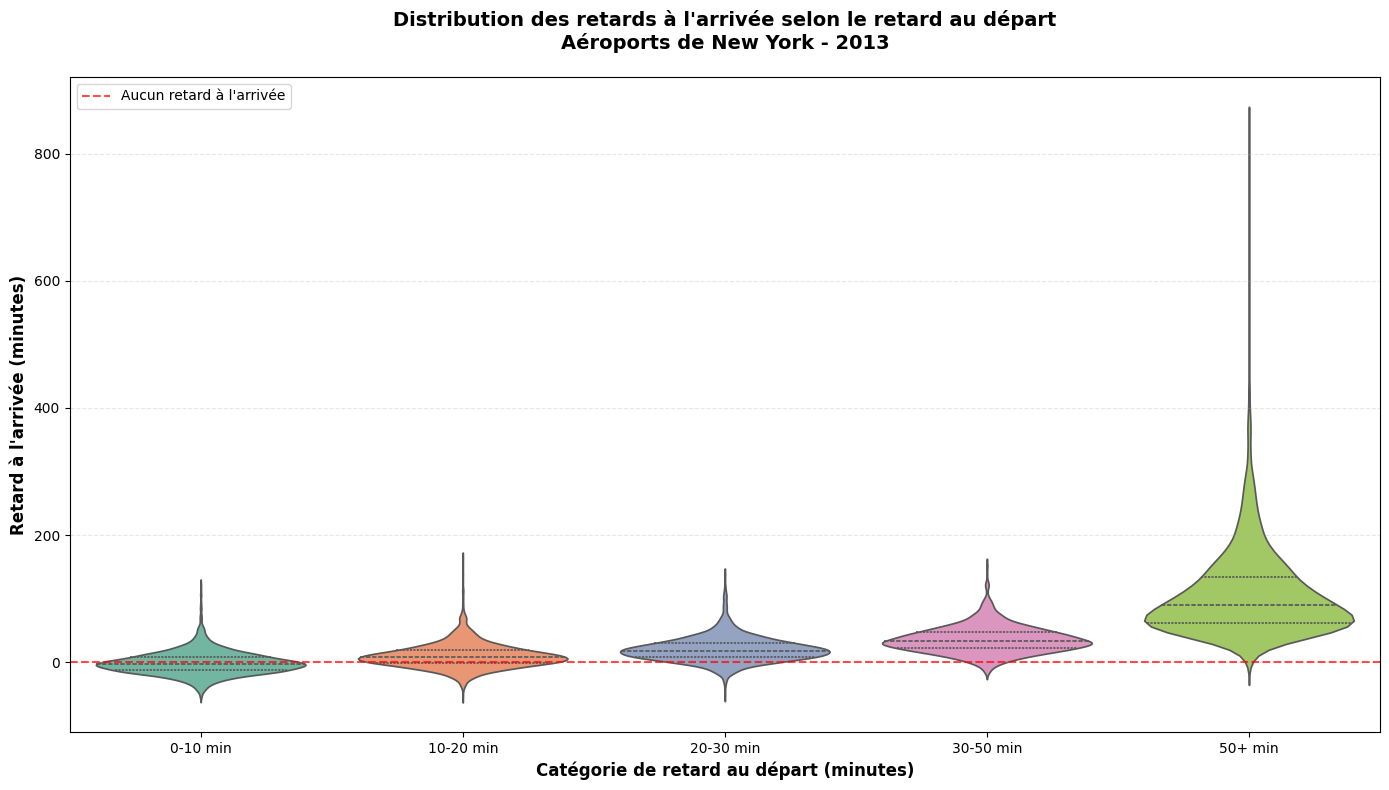


--- ANALYSE PAR CATÉGORIE ---
0-10 min: 56.4% des vols arrivent en avance (rattrapage total)
10-20 min: 27.7% des vols arrivent en avance (rattrapage total)
20-30 min: 10.3% des vols arrivent en avance (rattrapage total)
30-50 min: 2.5% des vols arrivent en avance (rattrapage total)
50+ min: 0.1% des vols arrivent en avance (rattrapage total)

--- RÉSUMÉ ----
Total de vols analysés (partis en retard) : 12,799
Retard moyen au départ : 39.50 minutes
Retard moyen à l'arrivée : 34.74 minutes
Rattrapage moyen : 4.76 minutes

✓ Conclusion : 74.1% des vols partis en retard arrivent EN RETARD.
✓ L'hypothèse est VALIDÉE : les retards au départ entraînent majoritairement des retards à l'arrivée.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# CHARGEMENT ET NETTOYAGE DES DONNÉES
df = pd.read_csv('nycflights.csv')

print("Forme de la base de données :", df.shape)

# Garder uniquement les vols EN RETARD au départ (peu importe arr_delay)
df_clean = df[df['dep_delay'] > 0].dropna(subset=['dep_delay', 'arr_delay']).copy()

print(f"Nombre de vols en retard au départ : {len(df_clean)}")

# ANALYSE DU RATTRAPAGE
# Calculer si le retard a été rattrapé, maintenu ou aggravé
df_clean['rattrapage'] = df_clean['dep_delay'] - df_clean['arr_delay']

vols_rattrapes = len(df_clean[df_clean['arr_delay'] < 0])  # Arrivée en avance malgré retard départ
vols_maintenus = len(df_clean[df_clean['rattrapage'].between(-5, 5)])  # Retard similaire
vols_aggraves = len(df_clean[df_clean['rattrapage'] < -5])  # Retard aggravé

print(f"\n--- ANALYSE DES VOLS EN RETARD AU DÉPART ---")
print(f"Vols ayant TOTALEMENT rattrapé (arrivée en avance) : {vols_rattrapes} ({vols_rattrapes/len(df_clean)*100:.1f}%)")
print(f"Vols avec retard maintenu (±5 min) : {vols_maintenus} ({vols_maintenus/len(df_clean)*100:.1f}%)")
print(f"Vols avec retard aggravé : {vols_aggraves} ({vols_aggraves/len(df_clean)*100:.1f}%)")

# PRÉPARATION DES DONNÉES
# Créer des catégories de retard au départ
df_clean['dep_delay_category'] = pd.cut(
    df_clean['dep_delay'],
    bins=[0, 10, 20, 30, 50, 1000],
    labels=['0-10 min', '10-20 min', '20-30 min', '30-50 min', '50+ min']
)

# Statistiques par catégorie
retards_par_categorie = df_clean.groupby('dep_delay_category', observed=True)['arr_delay'].agg(['mean', 'median', 'std', 'count'])

print("\n--- Retards à l'arrivée selon le retard au départ ---")
print(retards_par_categorie)

# CRÉATION DU VIOLINPLOT
fig, ax = plt.subplots(figsize=(14, 8))

sns.violinplot(
    data=df_clean,
    x='dep_delay_category',
    y='arr_delay',
    palette='Set2',
    inner='quartile',  # Affiche les quartiles
    ax=ax
)

# Formatage du graphique
ax.set_xlabel('Catégorie de retard au départ (minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Retard à l\'arrivée (minutes)', fontsize=12, fontweight='bold')
ax.set_title('Distribution des retards à l\'arrivée selon le retard au départ\nAéroports de New York - 2013',
             fontsize=14, fontweight='bold', pad=20)

# Ligne de référence à 0 (frontière entre avance et retard à l'arrivée)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Aucun retard à l\'arrivée')

ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()
# STATISTIQUES DÉTAILLÉES
print(f"\n--- ANALYSE PAR CATÉGORIE ---")
for cat in df_clean['dep_delay_category'].cat.categories:
    subset = df_clean[df_clean['dep_delay_category'] == cat]
    rattrapes = len(subset[subset['arr_delay'] < 0])
    pct = (rattrapes / len(subset)) * 100
    print(f"{cat}: {pct:.1f}% des vols arrivent en avance (rattrapage total)")
# STATISTIQUES FINALES
print(f"\n--- RÉSUMÉ ----")
print(f"Total de vols analysés (partis en retard) : {len(df_clean):,}")
print(f"Retard moyen au départ : {df_clean['dep_delay'].mean():.2f} minutes")
print(f"Retard moyen à l'arrivée : {df_clean['arr_delay'].mean():.2f} minutes")
print(f"Rattrapage moyen : {df_clean['rattrapage'].mean():.2f} minutes")
print(f"\n✓ Conclusion : {(len(df_clean) - vols_rattrapes) / len(df_clean) * 100:.1f}% des vols partis en retard arrivent EN RETARD.")
print(f"✓ L'hypothèse est VALIDÉE : les retards au départ entraînent majoritairement des retards à l'arrivée.")
